In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score

In [5]:
df = pd.read_csv(r"C:\Users\admin\Desktop\churn_project\churn_project\data\Churn.csv",sep=',')
df.head()
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [7]:
df_encoded = df.drop('customerID', axis=1)
num_col = df_encoded.select_dtypes(include=[np.number]).columns
cat_col = df_encoded.select_dtypes(include=object).columns

df[num_col] = df[num_col].fillna(df[num_col].median())
for col in cat_col:
    df[col] = df[col].fillna(df[col].mode()[0])

In [8]:
bynary_cat = [col for col in cat_col if len(df[col].unique()) == 2]
multi_cat = [col for col in cat_col if len(df[col].unique()) > 2]

label_encoders = {}
for i in bynary_cat:
    le = LabelEncoder()
    df_encoded[i] = le.fit_transform(df_encoded[i])
    label_encoders[i] = le

df_encoded = pd.get_dummies(df_encoded, columns=multi_cat, drop_first=True)

In [9]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.2)

scaler = StandardScaler()
X_train[num_col] = scaler.fit_transform(X_train[num_col])
X_test[num_col] = scaler.transform(X_test[num_col])

In [10]:
lr = LogisticRegression(random_state=42, max_iter=1000,class_weight='balanced')
lr.fit(X_train, y_train)
proba = lr.predict_proba(X_test)[:,1]
custom_pred = (proba > 0.4).astype(int)
print(classification_report(y_test, custom_pred))

              precision    recall  f1-score   support

           0       0.93      0.64      0.76      1035
           1       0.47      0.87      0.61       374

    accuracy                           0.70      1409
   macro avg       0.70      0.75      0.68      1409
weighted avg       0.81      0.70      0.72      1409



In [11]:
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [16]:
# %%
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)
gb_proba = gb.predict_proba(X_test)[:, 1]

print("Gradient Boosting Classification Report:")
print(classification_report(y_test, gb_pred))

print("GB ROC-AUC:", roc_auc_score(y_test, gb_proba))


Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

GB ROC-AUC: 0.8421194037562325


In [17]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3  # дисбаланс 3:1
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_pred))
print("XGB ROC-AUC:", roc_auc_score(y_test, xgb_proba))


              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

XGB ROC-AUC: 0.8415949779121135


In [12]:
print("LogReg ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))
print("RF ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

LogReg ROC-AUC: 0.8416905629181844
RF ROC-AUC: 0.820381565010721


In [13]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
coef_df.head(6)

,feature,coefficient
26,Contract_Two year,-1.413232
11,InternetService_Fiber optic,1.213162
4,tenure,-1.147059
25,Contract_One year,-0.716996
7,MonthlyCharges,-0.534915
8,TotalCharges,0.477240


In [14]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
feature_importance.head(6)

,feature,importance
8,TotalCharges,0.196280
4,tenure,0.169860
7,MonthlyCharges,0.168515
28,PaymentMethod_Electronic check,0.040664
11,InternetService_Fiber optic,0.036985
26,Contract_Two year,0.029986


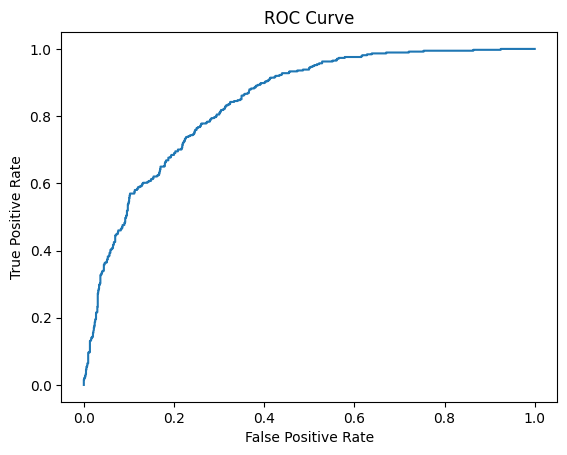

In [15]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, proba)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()